# DOE Petroleum Price Preprocessing

## Bug fixes applied

**Root cause:** `pdfplumber` table extraction silently merges vertically-adjacent cells in Types B–E, producing either a 47-column explosion (Types B/C) or multi-product blobs in a single cell (Types D/E). The original code tried to parse those malformed tables, which meant no records were detected.

**Fix:** Replaced all `page.extract_tables()` calls (for Types B–E) with a word-level approach using `page.extract_words()`. Words are bucketed by their x-position into brand columns (derived from the header row), and products are identified by parsing the product column text directly. Type A (2017 range-string format) still uses table extraction since that format has clean line-based tables.

**Additional fixes:**
- Product column boundary: product names sit ~20px left of their column header; use `product_header_x - 25` as the left boundary
- Product integer suffixes (`97`, `95`, `91`, `100`) were excluded by a decimal filter; fixed to only exclude strings with `.`
- Multi-line product names (`Gasoline` / `(RON97)` on consecutive rows) now assembled via intent-based grouping, not naive proximity (which merged all gasoline rows into one blob)
- Area names with garbled PDF encoding (e.g., `CMalaokoactai iCtyity` → `Makati City`) fixed via subsequence fuzzy matching against a known NCR cities list

In [19]:
import os
import re
import pdfplumber
import pandas as pd
from pathlib import Path
from collections import defaultdict
from dateutil import parser as dateparser
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [3]:
# --- Products ---
PRODUCTS_ORDER = [
    'RON 100', 'RON 97', 'RON 95', 'RON 91',
    'DIESEL PLUS', 'DIESEL', 'KEROSENE',
]

# Normalizes raw text tokens in the product column to canonical product names
PRODUCT_WORD_MAP = {
    'GASOLINE(RON97)': 'RON 97',
    'GASOLINE(RON95)': 'RON 95',
    'GASOLINE(RON91)': 'RON 91',
    'GASOLINE(RON100)': 'RON 100',
    'RON97':  'RON 97',
    'RON95':  'RON 95',
    'RON91':  'RON 91',
    'RON100': 'RON 100',
    'DIESELPLUS': 'DIESEL PLUS',
    'DIESEL':    'DIESEL',
    'KEROSENE':  'KEROSENE',
    'PREMIUMMINUS': 'RON 91',
    'PREMIUM':    'RON 95',
}

# --- Brands ---
BRAND_HEADERS = {
    'PETRON', 'SHELL', 'CALTEX', 'PHOENIX', 'TOTAL',
    'UNIOIL', 'SEAOIL', 'PTT', 'INDEPENDENT',
}  # FLYING V handled separately (two words)

# --- Metadata tokens to ignore in product/area columns ---
META_SKIP = {
    'NATIONAL', 'CAPITAL', 'REGION', 'MONITORING', 'PREVAILING', 'RETAIL',
    'PUMP', 'PRICES', 'Date', 'Effectivity', 'Cities', 'Monitoring', 'NCR',
    'Kagawaran', 'ng', 'Enerhiya', 'Oil', 'Industry', 'Management', 'Bureau',
    'Republic', 'Philippines', 'Department', 'Energy', 'Bagong', 'Pilipinas',
    'LFRO', 'NO', 'NONE', '#N/A', 'N/A', 'For', 'the', 'week', 'of', 'period',
    'PRICE', 'Product', 'Effectivity:', 'COMMON', 'PRICES', 'OF', 'As',
    'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December',
    '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026',
}

# --- Known NCR cities for fuzzy area normalization ---
KNOWN_CITIES = [
    'Caloocan', 'Quezon', 'Manila', 'Pasig', 'Taguig', 'Makati',
    'Parañaque', 'Muntinlupa', 'Pasay', 'Malabon', 'Mandaluyong',
    'Marikina', 'Las Piñas', 'Pateros', 'San Juan', 'Navotas', 'Valenzuela',
]

## Helper utilities

In [4]:
def normalize_area(raw: str) -> str:
    """
    Map a (possibly garbled) area string to a canonical NCR city name.

    Some DOE PDFs have encoding bugs that interleave characters from two adjacent
    city names (e.g. 'CMalaokoactai iCtyity' instead of 'Makati City'). A simple
    substring match handles clean text; a subsequence match recovers the garbled cases.
    """
    if not raw:
        return raw
    raw_clean = raw.strip()

    # 1. Direct substring match (handles clean text and abbreviations like 'Taguig Cty')
    for city in KNOWN_CITIES:
        if city.lower() in raw_clean.lower():
            suffix = '' if city in ('Manila', 'Pateros') else ' City'
            return city + suffix

    # 2. Subsequence / character-overlap match (handles garbled encoding)
    raw_lower = raw_clean.lower().replace(' ', '')
    best, best_score = None, 0.0
    for city in KNOWN_CITIES:
        city_lower = city.lower().replace(' ', '')
        ci = 0
        for ch in raw_lower:
            if ci < len(city_lower) and ch == city_lower[ci]:
                ci += 1
        score = ci / len(city_lower)
        if score > best_score:
            best_score, best = score, city
    if best_score >= 0.70:
        suffix = '' if best in ('Manila', 'Pateros') else ' City'
        return best + suffix

    return raw_clean


def lookup_timeline(timeline: list, y: float, tol: float = 25.0):
    """
    Return the most recent value in `timeline` whose y-anchor is <= y + tol.
    timeline is a list of (y_anchor, value) sorted ascending by y_anchor.
    """
    result = None
    for ey, val in timeline:
        if ey <= y + tol:
            result = val
    return result

In [5]:
def build_product_timeline(prod_words: list) -> list:
    """
    Convert a list of word dicts (from the product column) into a
    sorted (y_anchor, canonical_product_name) timeline.

    Key challenges handled:
    - Two-row product names: 'Gasoline' on one y, '(RON95)' on the next.
      Handled by intent-based look-ahead rather than proximity grouping,
      which would merge all gasoline rows into a single blob.
    - 'DIESEL' vs 'DIESEL PLUS': check whether 'PLUS' follows on the next word.
    - 'RON 97/95/91/100': suffix integer on the same or immediately next y row.
    - Integer tokens (97, 95 …) were previously excluded by a decimal filter;
      they are now kept because they carry no '.' character.
    """
    timeline = []
    prod_sorted = sorted(prod_words, key=lambda w: w['top'])
    i = 0

    while i < len(prod_sorted):
        w = prod_sorted[i]
        txt = w['text'].upper().replace('(', '').replace(')', '')

        # Skip metadata tokens
        if txt in META_SKIP or any(
            s in txt.lower()
            for s in ['effectiv', 'price', 'monitor', 'date', 'common', 'prevailing']
        ):
            i += 1
            continue

        # 'Gasoline (RON97)' split across two y rows
        if txt == 'GASOLINE' and i + 1 < len(prod_sorted):
            nxt = prod_sorted[i + 1]
            if abs(nxt['top'] - w['top']) < 20:
                sfx = nxt['text'].upper().replace('(', '').replace(')', '')
                combined = 'GASOLINE(' + sfx + ')'
                mapped = PRODUCT_WORD_MAP.get(combined)
                if mapped:
                    avg_y = (w['top'] + nxt['top']) / 2
                    timeline.append((avg_y, mapped))
                    i += 2
                    continue

        # 'Diesel' → check whether next word is 'Plus' (DIESEL PLUS)
        elif txt == 'DIESEL':
            if (
                i + 1 < len(prod_sorted)
                and prod_sorted[i + 1]['text'].upper() == 'PLUS'
                and abs(prod_sorted[i + 1]['top'] - w['top']) < 20
            ):
                avg_y = (w['top'] + prod_sorted[i + 1]['top']) / 2
                timeline.append((avg_y, 'DIESEL PLUS'))
                i += 2
                continue
            else:
                timeline.append((w['top'], 'DIESEL'))
                i += 1
                continue

        # 'RON' with numeric suffix on the same row (y-diff < 5)
        elif txt == 'RON' and i + 1 < len(prod_sorted):
            nxt = prod_sorted[i + 1]
            if abs(nxt['top'] - w['top']) < 5:
                sfx = nxt['text'].upper()
                mapped = PRODUCT_WORD_MAP.get('RON' + sfx)
                if mapped:
                    avg_y = (w['top'] + nxt['top']) / 2
                    timeline.append((avg_y, mapped))
                    i += 2
                    continue

        # Direct single-word match
        mapped = PRODUCT_WORD_MAP.get(txt)
        if mapped:
            timeline.append((w['top'], mapped))
        i += 1

    return timeline

In [6]:
def extract_header_geometry(words: list, header_y: float) -> dict:
    """
    From words near the header row, extract:
      brand_buckets   - list of (brand, x_min, x_max) tuples, sorted left→right
      first_brand_x   - left edge of the leftmost brand column
      overall_x       - left edge of OVERALL RANGE / COMMON PRICE exclusion zone
      product_col_left- left boundary of the product column
                        (product_header_x - 25 to handle slight left offset of text)
    """
    header_words = [w for w in words if abs(w['top'] - header_y) < 25]

    # Brand x-positions
    brand_x = {}
    for w in header_words:
        if w['text'].upper() in BRAND_HEADERS:
            brand_x[w['text'].upper()] = w['x0']
    fw = next((w for w in header_words if w['text'].upper() == 'FLYING'), None)
    if fw:
        brand_x['FLYING V'] = fw['x0']

    brands_sorted = sorted(brand_x.items(), key=lambda kv: kv[1])
    first_brand_x = brands_sorted[0][1] if brands_sorted else 9999

    # Exclusion zone: OVERALL RANGE / COMMON PRICE start
    excl_words = [w for w in header_words if w['text'].upper() in ('OVERALL', 'COMMON')]
    overall_x = min((w['x0'] for w in excl_words), default=99999)

    # Brand x-buckets (each brand owns x from its header to the next brand's header)
    brand_buckets = []
    for i, (brand, x0) in enumerate(brands_sorted):
        x1 = brands_sorted[i + 1][1] if i + 1 < len(brands_sorted) else overall_x
        brand_buckets.append((brand, x0 - 10, x1))  # -10 tolerates slight left offset

    # Product column left boundary
    prod_hdr = next((w for w in header_words if w['text'].upper() == 'PRODUCT'), None)
    product_header_x = prod_hdr['x0'] if prod_hdr else (first_brand_x - 100)
    product_col_left = product_header_x - 25  # product text sits ~20px left of header

    return {
        'brand_buckets':    brand_buckets,
        'first_brand_x':    first_brand_x,
        'overall_x':        overall_x,
        'product_col_left': product_col_left,
    }

## Parsers

In [7]:
def parse_type_a(pdf_path: str) -> pd.DataFrame:
    """
    Type A – 2017 early format.
    Multiple small brand tables per page; price values are 'XX.XX-XX.XX' range strings.
    No area breakdown. Table extraction works reliably here because the PDF uses
    actual line borders for this format.
    """
    records = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            tables = page.extract_tables({
                'vertical_strategy':   'lines',
                'horizontal_strategy': 'lines',
            })

            for table in tables:
                if not table or len(table) < 2:
                    continue
                header = [str(c).strip() if c else '' for c in table[0]]

                product_col = next(
                    (i for i, h in enumerate(header) if 'product' in h.lower()), 0
                )
                brand_cols = [
                    (i, header[i])
                    for i in range(len(header))
                    if i != product_col
                    and header[i]
                    and any(
                        b in header[i].lower()
                        for b in ['petron', 'shell', 'caltex', 'phoenix', 'total',
                                  'flying', 'unioil', 'seaoil', 'ptt', 'independent']
                    )
                ]

                for row in table[1:]:
                    if product_col >= len(row) or not row[product_col]:
                        continue
                    prod_raw = str(row[product_col]).strip().upper()
                    prod_raw_compact = prod_raw.replace(' ', '').replace('(', '').replace(')', '')

                    # Match against canonical products
                    prod = next(
                        (p for p in PRODUCTS_ORDER if p in prod_raw or prod_raw in p), None
                    ) or PRODUCT_WORD_MAP.get(prod_raw_compact)
                    if not prod:
                        continue

                    for col_i, brand in brand_cols:
                        if col_i >= len(row) or not row[col_i]:
                            continue
                        val = str(row[col_i]).strip()
                        m = re.match(r'([\d.]+)\s*[-–]\s*([\d.]+)', val)
                        if m:
                            records.append({
                                'product':   prod,
                                'brand':     brand.upper(),
                                'price_min': float(m.group(1)),
                                'price_max': float(m.group(2)),
                            })

    return pd.DataFrame(records) if records else pd.DataFrame()

In [8]:
def parse_type_bc(pdf_path: str) -> pd.DataFrame:
    """
    Types B & C – 2017 mid/late format.
    Single table, no area breakdown, paired brand columns (min, max).
    Type C adds Overall Range + Common Price columns (handled by the OVERALL_X exclusion).

    WHY NOT TABLE EXTRACTION:
    pdfplumber detects the PDF's visual alignment guide lines as column separators,
    producing a ~47-column table where brand data is scattered across sparse columns.
    The product names ('Gasoline' / '(RON95)') span two physical rows, so they end up
    in separate rows with a massive first merged group.

    FIX: Use word-level extraction. Brands are identified from their x-position
    in the header row; prices are bucketed by the same x-ranges.
    Products are reconstructed from the two-row name structure via look-ahead.
    """
    records = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            words = page.extract_words(x_tolerance=3, y_tolerance=3)
            if not words:
                continue

            # Anchor on the brand header row
            petron_w = next(
                (w for w in words if w['text'] in ('Petron', 'PETRON')), None
            )
            if not petron_w:
                continue
            header_y = petron_w['top']

            geom = extract_header_geometry(words, header_y)
            brand_buckets = geom['brand_buckets']
            first_brand_x = geom['first_brand_x']
            overall_x = geom['overall_x']

            data_words = [
                w for w in words
                if w['top'] > header_y + 10 and w['x0'] < overall_x
            ]

            # Product column: everything left of the first brand, no decimal prices
            prod_words = [
                w for w in data_words
                if w['x0'] < first_brand_x
                and '.' not in w['text']
                and w['text'] not in META_SKIP
            ]
            product_timeline = build_product_timeline(prod_words)

            # Price words: right of first brand, decimal format
            price_words = [
                w for w in data_words
                if w['x0'] >= first_brand_x and re.match(r'^\d+\.\d+$', w['text'])
            ]

            # Group prices by y-row (snap to 2pt grid)
            price_rows = defaultdict(list)
            for w in price_words:
                price_rows[round(w['top'] / 2) * 2].append(w)

            for y_key in sorted(price_rows.keys()):
                row = sorted(price_rows[y_key], key=lambda w: w['x0'])
                prod = lookup_timeline(product_timeline, y_key)
                if not prod:
                    continue

                brand_prices = defaultdict(list)
                for pw in row:
                    for brand, x0, x1 in brand_buckets:
                        if x0 <= pw['x0'] < x1:
                            brand_prices[brand].append(float(pw['text']))
                            break

                for brand, prices in brand_prices.items():
                    if len(prices) >= 2:
                        records.append({
                            'product':   prod,
                            'brand':     brand,
                            'price_min': min(prices[:2]),
                            'price_max': max(prices[:2]),
                        })
                    elif len(prices) == 1:
                        records.append({
                            'product':   prod,
                            'brand':     brand,
                            'price_min': prices[0],
                            'price_max': prices[0],
                        })

    return pd.DataFrame(records) if records else pd.DataFrame()

In [9]:
def parse_type_de(pdf_path: str) -> pd.DataFrame:
    """
    Types D & E – 2019-2021 and 2024-2026 area-based formats.

    WHY NOT TABLE EXTRACTION:
    pdfplumber merges all per-product price cells for one area into the first
    product row as a multi-line blob (e.g. '53.10 60.70\n51.70 59.20\n...').
    Subsequent rows for the same area have None for all brand columns.
    This makes it impossible to map prices to products using the table API.

    FIX: Use word-level extraction. Each price word has its own (x, y) coordinate.
    Products and areas are identified from their respective columns and tracked as
    timelines; each price word is then assigned to the most-recently-seen
    product/area at or above its y-position.

    Additional fix – area name garbling:
    Some PDFs have a font-encoding bug where two adjacent city names get character-
    interleaved ('CMalaokoactai iCtyity' instead of 'Makati City'). normalize_area()
    recovers the correct name via subsequence matching.
    """
    records = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            words = page.extract_words(x_tolerance=3, y_tolerance=3)
            if not words:
                continue

            petron_w = next((w for w in words if w['text'] == 'PETRON'), None)
            if not petron_w:
                continue
            header_y = petron_w['top']

            geom = extract_header_geometry(words, header_y)
            brand_buckets    = geom['brand_buckets']
            first_brand_x    = geom['first_brand_x']
            overall_x        = geom['overall_x']
            product_col_left = geom['product_col_left']

            data_words = [
                w for w in words
                if w['top'] > header_y + 10 and w['x0'] < overall_x
            ]

            # --- Product timeline ---
            # FIX: Use '.' not in text (not a float-filter regex) so that integer
            # suffixes like 97, 95, 91, 100 are included.
            prod_words = [
                w for w in data_words
                if product_col_left <= w['x0'] < first_brand_x
                and '.' not in w['text']       # exclude decimal prices, keep integer suffixes
                and w['text'] not in META_SKIP
            ]
            product_timeline = build_product_timeline(prod_words)

            # --- Area timeline ---
            area_words = [
                w for w in data_words
                if w['x0'] < product_col_left
                and '.' not in w['text']
                and w['text'] not in META_SKIP
                and not re.match(r'^\d+$', w['text'])
                and len(w['text']) > 2
            ]

            area_timeline = []
            pending, pending_y = [], None
            for w in sorted(area_words, key=lambda w: w['top']):
                skip = any(
                    x in w['text'].lower()
                    for x in ['date', 'effectiv', 'monitor', 'national',
                               'capital', 'region', 'republic', 'prevailing']
                )
                if skip:
                    if pending:
                        area_timeline.append(
                            (pending_y, normalize_area(' '.join(pending)))
                        )
                        pending, pending_y = [], None
                    continue

                if pending_y is None or abs(w['top'] - pending_y) < 8:
                    pending.append(w['text'])
                    if pending_y is None:
                        pending_y = w['top']
                else:
                    area_timeline.append(
                        (pending_y, normalize_area(' '.join(pending)))
                    )
                    pending, pending_y = [w['text']], w['top']

            if pending:
                area_timeline.append(
                    (pending_y, normalize_area(' '.join(pending)))
                )

            # --- Price words ---
            price_words = [
                w for w in data_words
                if w['x0'] >= first_brand_x
                and re.match(r'^\d+\.\d+$', w['text'])
            ]

            price_rows = defaultdict(list)
            for w in price_words:
                price_rows[round(w['top'] / 2) * 2].append(w)

            for y_key in sorted(price_rows.keys()):
                row = sorted(price_rows[y_key], key=lambda w: w['x0'])
                prod = lookup_timeline(product_timeline, y_key)
                area = lookup_timeline(area_timeline, y_key)
                if not prod:
                    continue

                brand_prices = defaultdict(list)
                for pw in row:
                    for brand, x0, x1 in brand_buckets:
                        if x0 <= pw['x0'] < x1:
                            brand_prices[brand].append(float(pw['text']))
                            break

                for brand, prices in brand_prices.items():
                    if len(prices) >= 2:
                        records.append({
                            'area':      area,
                            'product':   prod,
                            'brand':     brand,
                            'price_min': min(prices[:2]),
                            'price_max': max(prices[:2]),
                        })
                    elif len(prices) == 1:
                        records.append({
                            'area':      area,
                            'product':   prod,
                            'brand':     brand,
                            'price_min': prices[0],
                            'price_max': prices[0],
                        })

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)
    # Forward-fill area: records at top of page 1 before first area label gets None
    df['area'] = df['area'].ffill()
    return df

## Format detection & date extraction

In [10]:
def detect_format(pdf_path: str) -> str:
    """
    Returns 'A', 'B', 'C', 'D', or 'E'.

    A  2017 early   – split brand tables, XX.XX-XX.XX range strings, no areas
    B  2017 mid     – single table, no areas, no Overall Range / Common Price cols
    C  2017 late/18 – single table, no areas, WITH Overall Range + Common Price cols
    D  2019-2021    – area-based, header in UPPERCASE, 'Date of Effectivity' date
    E  2024-2026    – area-based, 'Price Monitoring of Liquid Fuels' title
    """
    with pdfplumber.open(pdf_path) as pdf:
        page  = pdf.pages[0]
        text  = (page.extract_text() or '').lower()
        words = page.extract_words(x_tolerance=3, y_tolerance=3)

        # Type E: modern DOE format
        if 'price monitoring of liquid fuels' in text or 'bagong pilipinas' in text:
            return 'E'

        # Type A: contains range strings like '42.20-47.85'
        if any(
            re.search(r'\d+\.\d+-\d+\.\d+', w['text'])
            for w in words
        ):
            return 'A'

        # Area-based check
        has_areas = any(
            kw in text for kw in ['caloocan', 'quezon city', 'manila city', 'pasig city']
        )

        if has_areas:
            return 'D'

        # Single table: B vs C
        if 'overall' in text or ('common' in text and 'price' in text):
            return 'C'

        return 'B'

In [11]:
def extract_effectivity_date(pdf_path: str):
    """
    Extract the price effectivity date from a DOE bulletin.

    Handles all 5 format variants:
      A/B/C  "Effectivity: February 07, 2017"
      D      "Date of Effectivity: June 11, 2019"
      E      "For the week of January 6-12, 2026" → takes the start date
             "For the period of March 5-11, 2024" → takes the start date
    """
    with pdfplumber.open(pdf_path) as pdf:
        full_text = ''.join(
            (p.extract_text() or '') + '\n' for p in pdf.pages
        )

    # Pattern 1: "Effectivity: <date>" or "Date of Effectivity: <date>"
    m = re.search(
        r'(?:Date of\s+)?Effectivity\s*[:\-]\s*([A-Za-z]+\s+\d{1,2},?\s*\d{4})',
        full_text, re.IGNORECASE
    )
    if m:
        try:
            return dateparser.parse(m.group(1)).date()
        except Exception:
            pass

    # Pattern 2: "For the week/period of <start_date> - <end>"
    m = re.search(
        r'For the (?:week|period) of\s+'
        r'([A-Za-z]+\s+\d{1,2})\s*[-–]\s*(?:[A-Za-z]+\s+)?\d{1,2},?\s*(\d{4})',
        full_text, re.IGNORECASE
    )
    if m:
        try:
            return dateparser.parse(f'{m.group(1)} {m.group(2)}').date()
        except Exception:
            pass

    # Pattern 3: "As of <date>"
    m = re.search(
        r'As of\s*[:\-]?\s*([A-Za-z]+\s+\d{1,2},?\s*\d{4})',
        full_text, re.IGNORECASE
    )
    if m:
        try:
            return dateparser.parse(m.group(1)).date()
        except Exception:
            pass

    print(f'  ⚠ Could not extract effectivity date from {Path(pdf_path).name}')
    return None

## Execution pipeline

In [12]:
def parse_bulletin(pdf_path: str) -> dict:
    """
    Detect format, extract date, run the appropriate parser.
    Returns a dict with keys: format, effectivity_date, detail (DataFrame).
    """
    pdf_path = str(pdf_path)
    fmt = detect_format(pdf_path)
    effectivity_date = extract_effectivity_date(pdf_path)
    year = effectivity_date.year if effectivity_date else None

    print(f'  → Format: {fmt} | Effectivity: {effectivity_date}')

    if fmt == 'A':
        df = parse_type_a(pdf_path)
    elif fmt in ('B', 'C'):
        df = parse_type_bc(pdf_path)
    else:  # D or E
        df = parse_type_de(pdf_path)

    if df is not None and not df.empty:
        df['effectivity_date'] = effectivity_date
        df['year']             = year
        df['source']           = Path(pdf_path).name
        df['format']           = fmt

    return {
        'format':           fmt,
        'effectivity_date': effectivity_date,
        'detail':           df,
    }


def run_all(pdf_list: list) -> dict:
    results = {}
    for path in pdf_list:
        name = Path(path).name
        print(f'Processing: {name}')
        try:
            results[name] = parse_bulletin(path)
            count = len(results[name]['detail'])
            print(f'  → {count} rows extracted\n')
        except Exception as e:
            import traceback
            print(f'  → ERROR: {e}')
            traceback.print_exc()
            results[name] = {'format': None, 'effectivity_date': None, 'detail': pd.DataFrame()}
    return results


def build_pdf_list(base_folder_path: str) -> list:
    pdf_list = []
    base_folder = Path(base_folder_path)

    if not base_folder.exists():
        print(f'Base folder not found: {base_folder}')
        return pdf_list

    for subfolder in sorted(base_folder.iterdir()):
        if subfolder.is_dir():
            pdfs = sorted([
                str(f) for f in subfolder.iterdir()
                if f.is_file() and f.suffix.lower() == '.pdf'
            ])
            print(f'{len(pdfs)} files found in {subfolder.name}')
            pdf_list.extend(pdfs)

    print(f'\nTotal PDFs to process: {len(pdf_list)}')
    return pdf_list

In [13]:
target_directory = Path('../data/raw/doe_pdfs_v2')
pdf_list = build_pdf_list(target_directory)
results = run_all(pdf_list)

111 files found in Format 1
235 files found in Format 2
79 files found in Format 3
14 files found in Format 4
11 files found in Format 5

Total PDFs to process: 450
Processing: ncr-price-monitoring-01062026.pdf
  → Format: E | Effectivity: 2026-01-06
  → 387 rows extracted

Processing: ncr-price-monitoring-01132026.pdf
  → Format: E | Effectivity: 2026-01-13
  → 387 rows extracted

Processing: ncr-price-monitoring-01202026.pdf
  → Format: E | Effectivity: 2026-01-20
  → 375 rows extracted

Processing: ncr-price-monitoring-01272026.pdf
  → Format: E | Effectivity: 2026-01-27
  → 377 rows extracted

Processing: ncr-price-monitoring-02032026.pdf
  → Format: E | Effectivity: 2026-02-03
  → 375 rows extracted

Processing: ncr-price-monitoring-02102026-1.pdf
  → Format: E | Effectivity: 2026-02-10
  → 373 rows extracted

Processing: ncr-price-monitoring-02172026.pdf
  → Format: E | Effectivity: 2026-02-17
  → 375 rows extracted

Processing: ncr-price-monitoring-02242026.pdf
  → Format: E | E

In [16]:
# Combine all detail DataFrames
all_dfs = [v['detail'] for v in results.values() if v['detail'] is not None and not v['detail'].empty]
df_all = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
print(f'Total records: {len(df_all)}')
df_all.head(1000)

Total records: 125575


,area,product,brand,price_min,price_max,effectivity_date,year,source,format
0,NaN,RON 97,PETRON,70.00,70.00,2026-01-06,2026,ncr-price-monitoring-01062026.pdf,E
1,NaN,RON 97,SHELL,71.03,71.03,2026-01-06,2026,ncr-price-monitoring-01062026.pdf,E
2,NaN,RON 97,UNIOIL,52.15,52.15,2026-01-06,2026,ncr-price-monitoring-01062026.pdf,E
3,NaN,RON 97,SEAOIL,55.29,55.29,2026-01-06,2026,ncr-price-monitoring-01062026.pdf,E
4,NaN,RON 95,INDEPENDENT,52.15,52.15,2026-01-06,2026,ncr-price-monitoring-01062026.pdf,E
...,...,...,...,...,...,...,...,...,...
995,Makati City,KEROSENE,PETRON,54.45,56.44,2026-01-20,2026,ncr-price-monitoring-01202026.pdf,E
996,Makati City,KEROSENE,SHELL,55.51,57.49,2026-01-20,2026,ncr-price-monitoring-01202026.pdf,E
997,Makati City,KEROSENE,CALTEX,55.50,59.49,2026-01-20,2026,ncr-price-monitoring-01202026.pdf,E
998,Makati City,KEROSENE,PHOENIX,55.50,55.50,2026-01-20,2026,ncr-price-monitoring-01202026.pdf,E


In [17]:
df_all.isna().sum()

area                3424
product                0
brand                  0
price_min              0
price_max              0
effectivity_date     923
year                 923
source                 0
format                 0
dtype: int64

In [18]:
df_all.isna().sum(axis=1)

0         1
1         1
2         1
3         1
4         1
         ..
125570    1
125571    1
125572    1
125573    1
125574    1
Length: 125575, dtype: int64

In [22]:
print(df_all.columns.tolist())

['area', 'product', 'brand', 'price_min', 'price_max', 'effectivity_date', 'year', 'source', 'format']


In [ ]:
df_all.price_min.describe()

### Product Inspection

In [23]:
df_diesel = df_all[df_all['product'] == 'DIESEL'].copy()

df_diesel['average_price'] = (df_diesel['price_min'] + df_diesel['price_max']) / 2


In [24]:
print(df_diesel[['effectivity_date', 'area', 'brand', 'average_price']].head())

   effectivity_date           area     brand  average_price
13       2026-01-06  Caloocan City    PETRON         57.625
14       2026-01-06  Caloocan City     SHELL         59.700
15       2026-01-06  Caloocan City    CALTEX         59.300
16       2026-01-06  Caloocan City     TOTAL         49.900
17       2026-01-06  Caloocan City  FLYING V         53.845


In [63]:
df_all['effectivity_date'] = pd.to_datetime(df_all['effectivity_date'], errors='coerce')

print(df_all['effectivity_date'].min())
print(df_all['effectivity_date'].max())

2001-04-16 00:00:00
2201-03-26 00:00:00


In [64]:
mask = (df_all['effectivity_date'].dt.year < 2017) | (df_all['effectivity_date'].dt.year > 2026)
df_all[mask][['source', 'effectivity_date']].drop_duplicates()

,source,effectivity_date
112741,petro_mm_2019_april_17.pdf,2001-04-16
113980,petro_mm_2019_february_14.pdf,2201-02-12
113991,petro_mm_2019_february_21.pdf,2201-02-19
115073,petro_mm_2019_march_28.pdf,2201-03-26


In [69]:
df_all['effectivity_date'] = df_all['effectivity_date'].replace({
    pd.Timestamp('2001-04-16'): pd.Timestamp('2019-04-17'),
    pd.Timestamp('2201-03-26'): pd.Timestamp('2019-03-28'),
    pd.Timestamp('2011-03-28'): pd.Timestamp('2018-04-02'),
    pd.Timestamp('2011-08-14'): pd.Timestamp('2018-08-16'),
    pd.Timestamp('2011-08-21'): pd.Timestamp('2018-08-23'),
    pd.Timestamp('2011-08-28'): pd.Timestamp('2018-08-30'),
    pd.Timestamp('2011-10-02'): pd.Timestamp('2018-10-04'),
    pd.Timestamp('2011-10-09'): pd.Timestamp('2018-10-11'),
    pd.Timestamp('2011-04-16'): pd.Timestamp('2019-04-04'),
    pd.Timestamp('2001-04-23'): pd.Timestamp('2019-04-11'),
    pd.Timestamp('2201-02-12'): pd.Timestamp('2019-02-14'),
    pd.Timestamp('2201-02-19'): pd.Timestamp('2019-02-21'),
    pd.Timestamp('2011-03-12'): pd.Timestamp('2019-03-28'),
    pd.Timestamp('2011-04-02'): pd.Timestamp('2019-04-04')
})

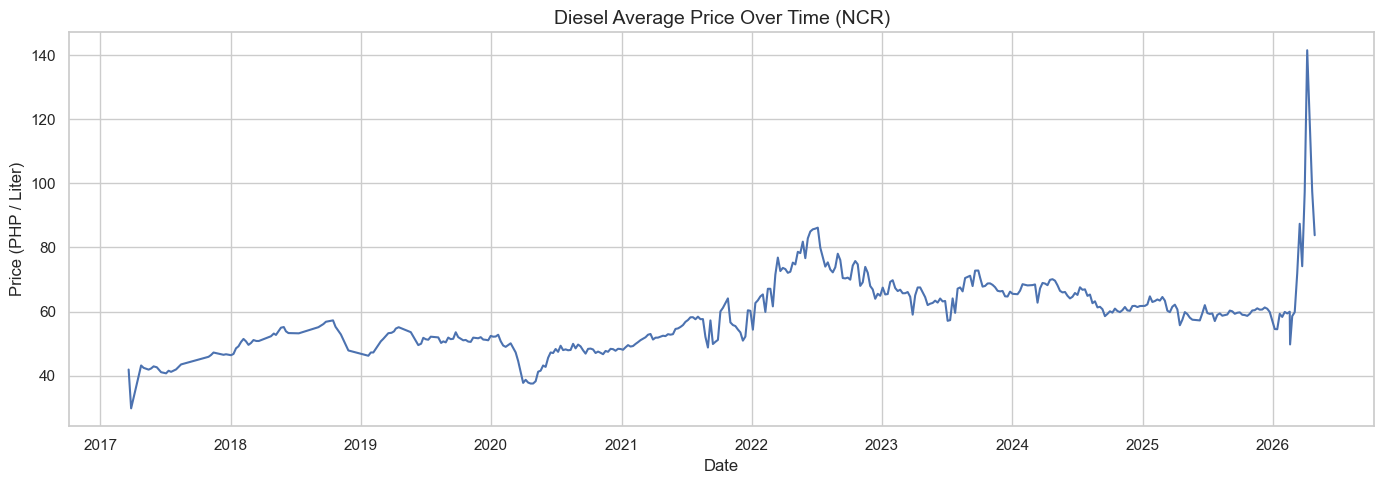

In [79]:
sns.set_theme(style='whitegrid')

# Midpoint price per record
df_all['price_mid'] = (df_all['price_min'] + df_all['price_max']) / 2

# Weekly average across all brands and areas
df_weekly = (
    df_all[df_all['product'] == 'DIESEL']
    .groupby('effectivity_date', as_index=False)['price_mid']
    .mean()
)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=df_weekly, x='effectivity_date', y='price_mid', ax=ax)

ax.set_title('Diesel Average Price Over Time (NCR)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP / Liter)')
plt.tight_layout()
plt.show()

In [35]:
df_all[df_all['effectivity_date'] < '2017-01-03'][['source', 'effectivity_date', 'price_min', 'price_max']].drop_duplicates('source')

,source,effectivity_date,price_min,price_max
122214,petro_mm_2019_april_04.pdf,2011-04-02,53.11,62.26


In [72]:
idx = df_all[df_all['effectivity_date'].dt.year == 2019]['price_max'].idxmax()
df_all.loc[idx]

area                                     NaN
product                               RON 97
brand                                  SHELL
price_min                             662.66
price_max                             662.66
effectivity_date         2019-05-07 00:00:00
year                                    2019
source              petro_mm_2019_may_09.pdf
format                                     C
price_mid                             662.66
Name: 124745, dtype: object

In [74]:
df_all = df_all.drop(124745).reset_index(drop=True)

In [ ]:
df_all[df_all['price_max'] > 200][['source', 'effectivity_date', 'product', 'brand', 'price_min', 'price_max']]

,source,effectivity_date,product,brand,price_min,price_max


In [77]:
df_all = df_all[df_all['price_max'] <= 200].reset_index(drop=True)

In [36]:
df_all['effectivity_date'].dt.year.value_counts().sort_index()

effectivity_date
2011.0       30
2017.0      901
2018.0     1199
2019.0     8272
2020.0    14147
2021.0    16417
2022.0    19714
2023.0    19079
2024.0    18602
2025.0    18669
2026.0     7622
Name: count, dtype: int64

In [37]:
df_all[df_all['effectivity_date'].dt.year == 2011][['source', 'effectivity_date']].drop_duplicates('source')

,source,effectivity_date
122214,petro_mm_2019_april_04.pdf,2011-04-02


In [54]:
df_all['effectivity_date'] = pd.to_datetime(df_all['effectivity_date'], errors='coerce')

In [58]:
df_all = df_all.reset_index(drop=True)

In [68]:
all_dfs = [v['detail'] for v in results.values() if v['detail'] is not None and not v['detail'].empty]
df_all = pd.concat(all_dfs, ignore_index=True)

# Then reapply all your fixes in order
df_all['effectivity_date'] = pd.to_datetime(df_all['effectivity_date'], errors='coerce')


In [80]:
df_weekly = (
    df_all
    .groupby(['effectivity_date', 'product'], as_index=False)['price_mid']
    .mean()
)

In [81]:
df_all['price_mid'] = (df_all['price_min'] + df_all['price_max']) / 2

In [82]:
df_weekly.head(10)

,effectivity_date,product,price_mid
0,2017-01-03,DIESEL PLUS,32.271667
1,2017-01-03,KEROSENE,39.263333
2,2017-01-03,RON 100,47.725000
3,2017-01-03,RON 91,43.449286
4,2017-01-03,RON 95,44.860833
5,2017-01-03,RON 97,47.175000
6,2017-01-10,DIESEL PLUS,32.371667
7,2017-01-10,KEROSENE,39.113333
8,2017-01-10,RON 100,47.725000
9,2017-01-10,RON 91,43.449286


In [95]:
df_weekly.isna().sum()

effectivity_date    0
product             0
price_mid           0
dtype: int64

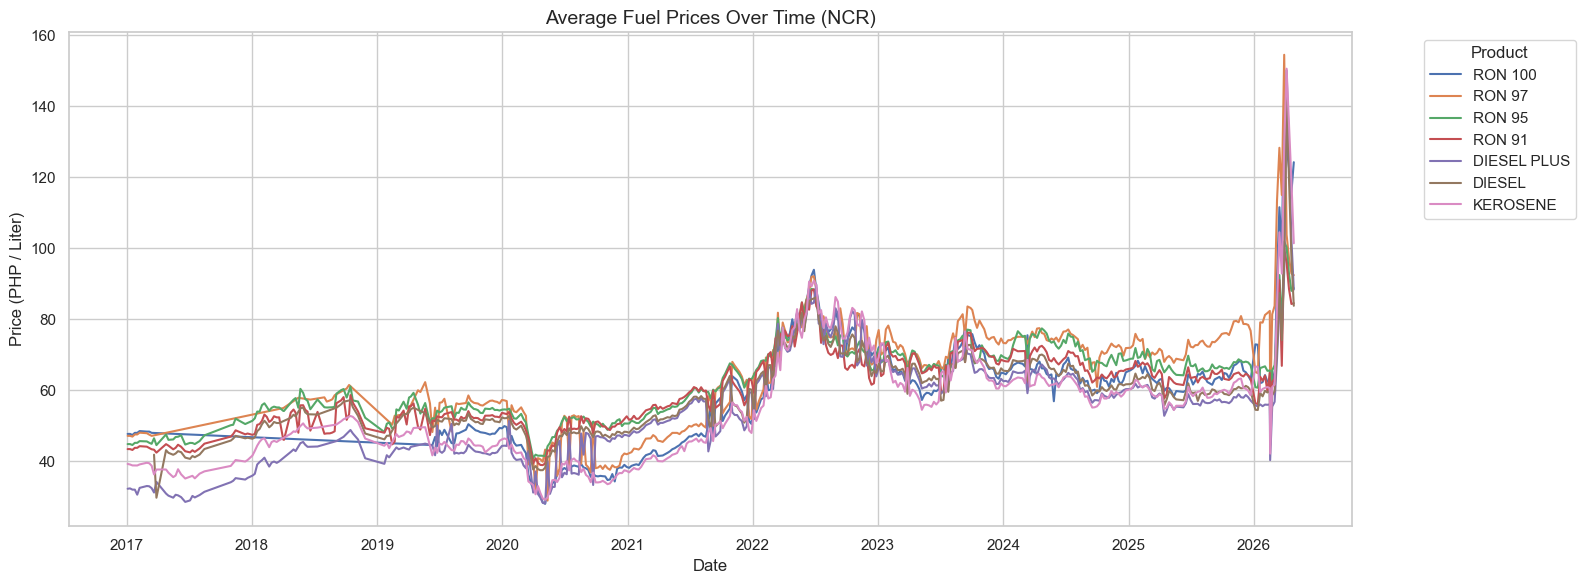

In [83]:
fig, ax = plt.subplots(figsize=(16, 6))

sns.lineplot(
    data=df_weekly,
    x='effectivity_date',
    y='price_mid',
    hue='product',
    hue_order=PRODUCTS_ORDER,
    ax=ax
)

ax.set_title('Average Fuel Prices Over Time (NCR)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP / Liter)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Product')
plt.tight_layout()
plt.show()

In [84]:
#Averaged weekly prices across all products for a cleaner overall trendline

df_weekly.to_csv('../data/semi-cleaned/weekly_avg_prices.csv', index=False)
df_weekly.to_parquet('../data/semi-cleaned/weekly_avg_prices.parquet', index=False)

# Save the full cleaned dataset as well
df_all.to_csv('../data/semi-cleaned/full_price_data.csv', index=False)
df_all.to_parquet('../data/semi-cleaned/full_price_data.parquet', index=False)

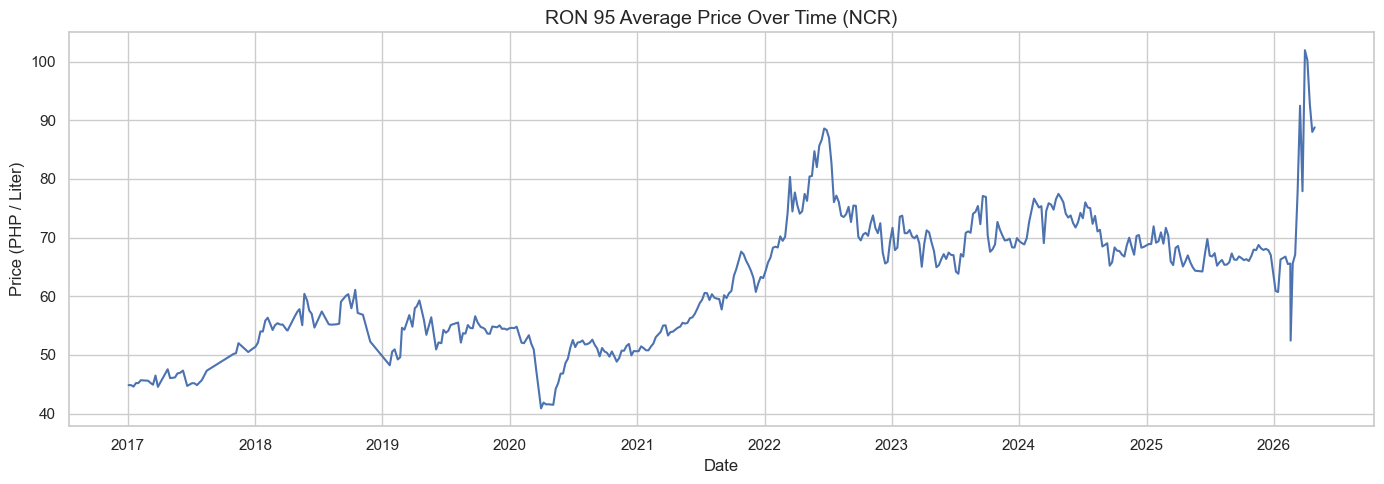

In [88]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=df_weekly[df_weekly['product'] == 'RON 95'],
    x='effectivity_date',
    y='price_mid',
    ax=ax
)

ax.set_title('RON 95 Average Price Over Time (NCR)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP / Liter)')
plt.tight_layout()
plt.show()

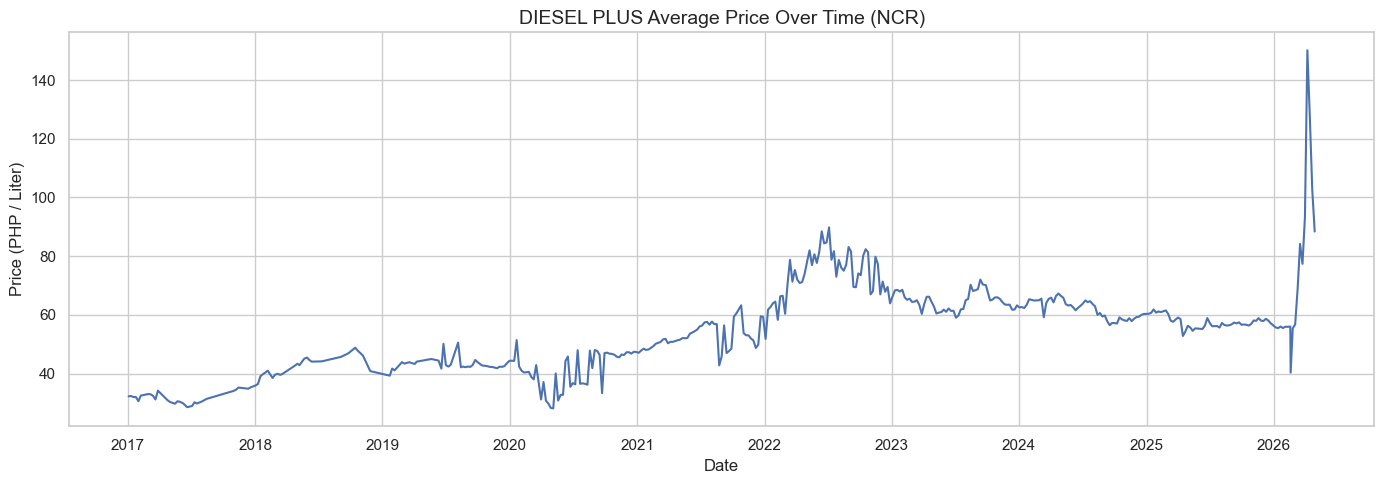

In [89]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=df_weekly[df_weekly['product'] == 'DIESEL PLUS'],
    x='effectivity_date',
    y='price_mid',
    ax=ax
)

ax.set_title('DIESEL PLUS Average Price Over Time (NCR)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP / Liter)')
plt.tight_layout()
plt.show()

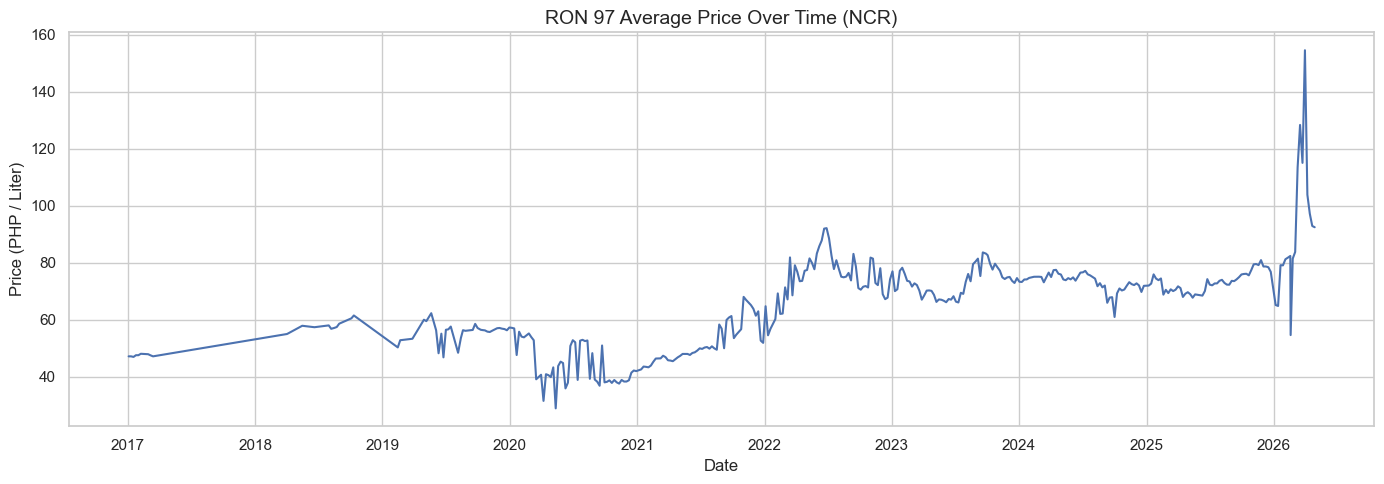

In [90]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=df_weekly[df_weekly['product'] == 'RON 97'],
    x='effectivity_date',
    y='price_mid',
    ax=ax
)

ax.set_title('RON 97 Average Price Over Time (NCR)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP / Liter)')
plt.tight_layout()
plt.show()

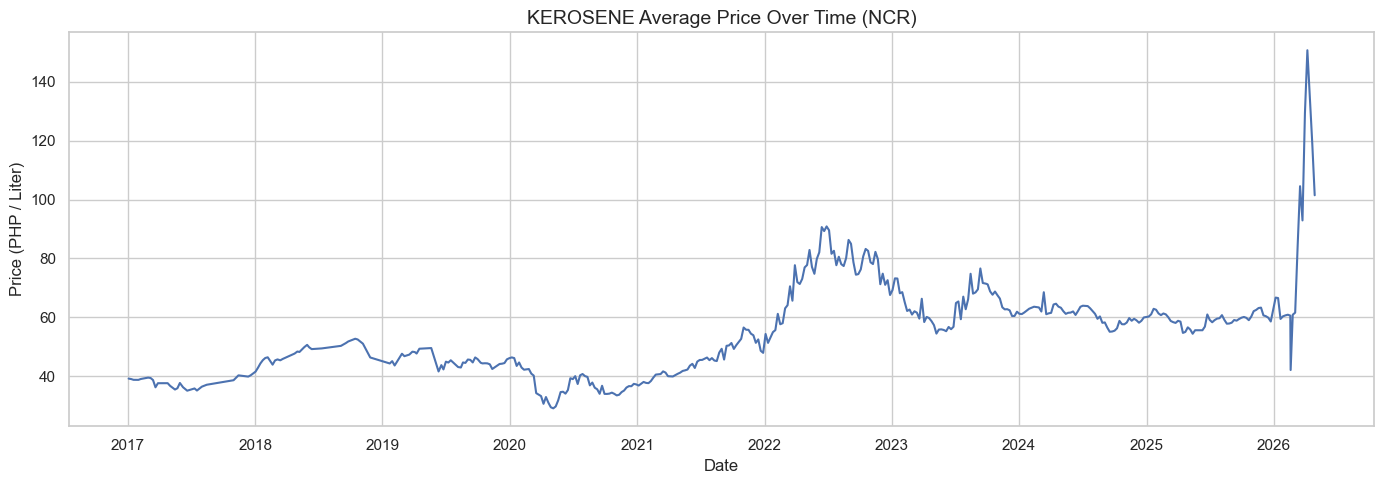

In [92]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=df_weekly[df_weekly['product'] == 'KEROSENE'],
    x='effectivity_date',
    y='price_mid',
    ax=ax
)

ax.set_title('KEROSENE Average Price Over Time (NCR)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP / Liter)')
plt.tight_layout()
plt.show()

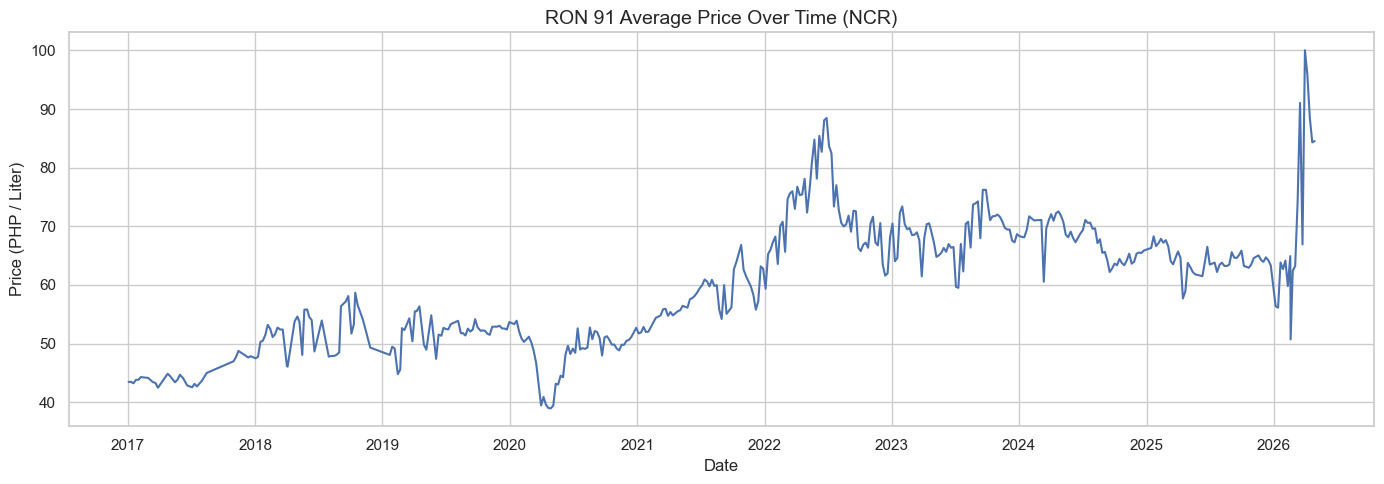

In [93]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=df_weekly[df_weekly['product'] == 'RON 91'],
    x='effectivity_date',
    y='price_mid',
    ax=ax
)

ax.set_title('RON 91 Average Price Over Time (NCR)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP / Liter)')
plt.tight_layout()
plt.show()

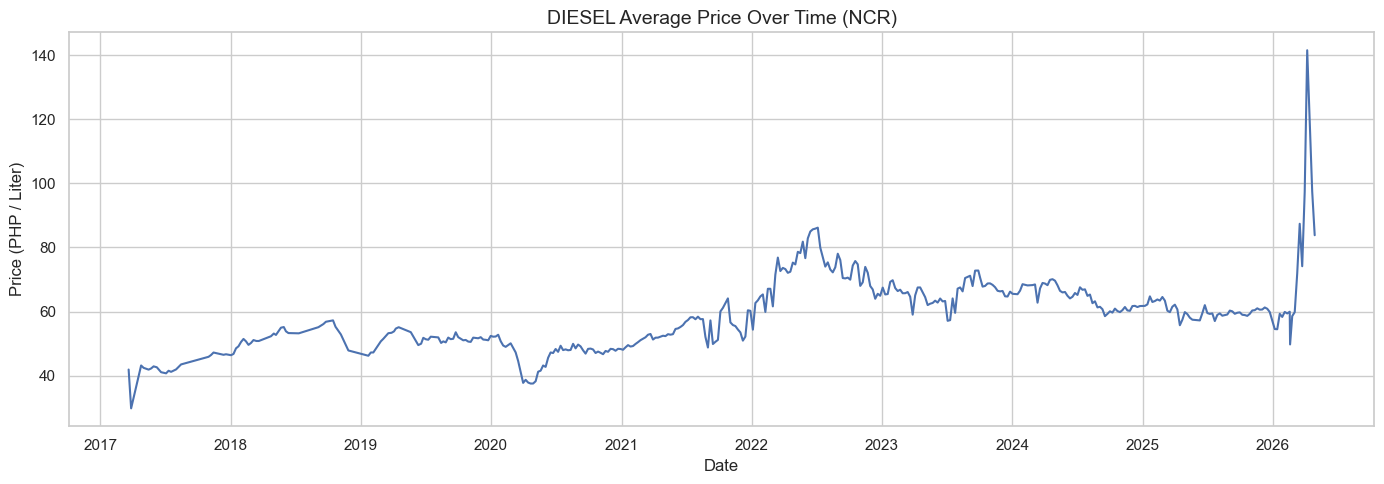

In [94]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=df_weekly[df_weekly['product'] == 'DIESEL'],
    x='effectivity_date',
    y='price_mid',
    ax=ax
)

ax.set_title('DIESEL Average Price Over Time (NCR)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (PHP / Liter)')
plt.tight_layout()
plt.show()